## Extract Lineages

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
#print(smf)
import covasim as cv

print(cv.__file__)
print(hasattr(cv, "Sim"))
print(cv.Sim)
import optuna

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
/storage/hcraddock/GitHub/covasim4wastewater/covasim/__init__.py
True
<class 'covasim.sim.Sim'>


## Data

In [33]:
DATA_ROOT = Path.home() / "GitHub"
WW_REPO = DATA_ROOT / "SARS-CoV-2_WasteWater_San-Diego"
CASES_REPO = DATA_ROOT / "lone_pine" / "resources"

In [34]:
zips = pd.read_csv(WW_REPO / "Zipcodes.csv")

In [36]:
zips.head(10)

,Zip_code,Community,Wastewater_treatment_plant
0,91901,Alpine,Point Loma
1,91902,Bonita,Point Loma
2,91910,Chula Vista,Point Loma
3,91911,Chula Vista,Point Loma
4,91913,Chula Vista,Point Loma
5,91914,Chula Vista,Point Loma
6,91915,Chula Vista,Point Loma
7,91932,Imperial Beach,South Bay
8,91941,La Mesa,Point Loma
9,91942,La Mesa,Point Loma


In [7]:
df_seqs = pd.read_csv(CASES_REPO / "sequences.csv", parse_dates=["collection_date"])

In [ ]:
df_seqs.head() #Not date ordered

,ID,collection_date,zipcode,epiweek,days_past,sequencer,provider,lineage,state
0,SEARCH-65663,2022-01-03,1721.0,2022-01-02,786,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.1,San Diego
1,SEARCH-65927,2022-01-05,7030.0,2022-01-02,784,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.1,San Diego
2,SEARCH-65942,2022-01-05,7030.0,2022-01-02,784,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.1,San Diego
3,SEARCH-67218,2022-01-06,5658.0,2022-01-02,783,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.1,San Diego
4,SEARCH-68516,2022-01-10,6612.0,2022-01-09,779,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.20,San Diego


In [21]:
df_seqs["collection_date"] = pd.to_datetime(df_seqs["collection_date"])
print(df_seqs["collection_date"].dt.to_period("M").value_counts().sort_index().loc["2021-01":"2022-03"])

collection_date
2021-01     6430
2021-02     5020
2021-03     2507
2021-04     1318
2021-05      602
2021-06      458
2021-07     3280
2021-08     7194
2021-09     3900
2021-10     3143
2021-11     3335
2021-12     7353
2022-01    13075
2022-02     1916
2022-03      700
Freq: M, Name: count, dtype: int64


In [ ]:
df_seq_sd["collection_date"] = pd.to_datetime(df_seq_sd["collection_date"])
print(df_seq_sd["collection_date"].dt.to_period("M").value_counts().sort_index().loc["2021-01":"2022-03"])

collection_date
2021-01     6386
2021-02     4995
2021-03     2496
2021-04     1316
2021-05      597
2021-06      444
2021-07     3219
2021-08     7176
2021-09     3777
2021-10     3110
2021-11     3106
2021-12     7323
2022-01    12805
2022-02     1863
2022-03      700
Freq: M, Name: count, dtype: int64


In [9]:
#Inspect
print(df_seqs.shape, df_seqs.columns.tolist())
print(df_seqs["collection_date"].min(), df_seqs["collection_date"].max())

(92400, 9) ['ID', 'collection_date', 'zipcode', 'epiweek', 'days_past', 'sequencer', 'provider', 'lineage', 'state']
2020-01-20 00:00:00 2024-02-28 00:00:00


In [10]:
#Inspect
print(df_seqs["lineage"].value_counts().head(15))

lineage
BA.1.1       11271
AY.103        4402
AY.44         3928
B.1.429       3789
BA.2.12.1     3444
BA.1          2973
BA.1.15       2494
B.1.427       2174
B.1.2         2123
BA.5.2.1      1926
AY.25         1918
B.1.1.7       1822
BA.2          1815
AY.26         1813
B.1           1634
Name: count, dtype: int64


## 2. Lineage Functions

In [15]:
def map_variant(l):
    l = str(l).strip()
    
    if l == "B.1.1.7" or l.startswith("Q."):
        return "alpha"
    if l == "P.1" or l.startswith("P.1."):
        return "gamma"
    if l == "B.1.617.2" or l.startswith("AY."):
        return "delta"
    if l in ("B.1.429", "B.1.427"):
        return "epsilon"
    
    # Catching BA.* and all subsequent compressed Omicron aliases
    # Common ones: BA, BQ, XBB, JN, KP, EG, CH, etc.
    if l.startswith("BA.") or l == "B.1.1.529":
        return "omicron"
    if l.startswith(("BQ.", "XBB.", "JN.", "KP.", "EG.", "CH.")): 
        return "omicron"
        
    return "other"


## 3. Extract SD Lineages

In [11]:
df_seq_sd = df_seqs[df_seqs["state"] == "San Diego"].copy()

In [16]:
df_seq_sd["variant"] = df_seq_sd["lineage"].map(map_variant)
print(df_seq_sd.groupby("variant")["lineage"].nunique())

variant
alpha        2
delta       91
epsilon      2
gamma        8
omicron    517
other      636
Name: lineage, dtype: int64


In [12]:
df_seq_sd.head()

,ID,collection_date,zipcode,epiweek,days_past,sequencer,provider,lineage,state
0,SEARCH-65663,2022-01-03,1721.0,2022-01-02,786,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.1,San Diego
1,SEARCH-65927,2022-01-05,7030.0,2022-01-02,784,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.1,San Diego
2,SEARCH-65942,2022-01-05,7030.0,2022-01-02,784,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.1,San Diego
3,SEARCH-67218,2022-01-06,5658.0,2022-01-02,783,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.1,San Diego
4,SEARCH-68516,2022-01-10,6612.0,2022-01-09,779,UCSD EXCITE Lab,UCSD EXCITE Lab,BA.1.20,San Diego


In [13]:
df_seq_sd.tail()

,ID,collection_date,zipcode,epiweek,days_past,sequencer,provider,lineage,state
92395,SEARCH-139952,2024-02-16,91902.0,2024-02-11,12,Andersen Lab,Sharp Health,JN.1,San Diego
92396,SEARCH-139953,2024-02-17,92104.0,2024-02-11,11,Andersen Lab,Sharp Health,JN.1,San Diego
92397,SEARCH-139954,2024-02-19,91942.0,2024-02-18,9,Andersen Lab,Sharp Health,JN.1,San Diego
92398,SEARCH-139955,2024-02-17,92154.0,2024-02-11,11,Andersen Lab,Sharp Health,JN.1.4,San Diego
92399,SEARCH-139956,2024-02-17,92037.0,2024-02-11,11,Andersen Lab,Sharp Health,KQ.1,San Diego


In [14]:
df_seq_sd['lineage'].nunique()

1256

### Plot

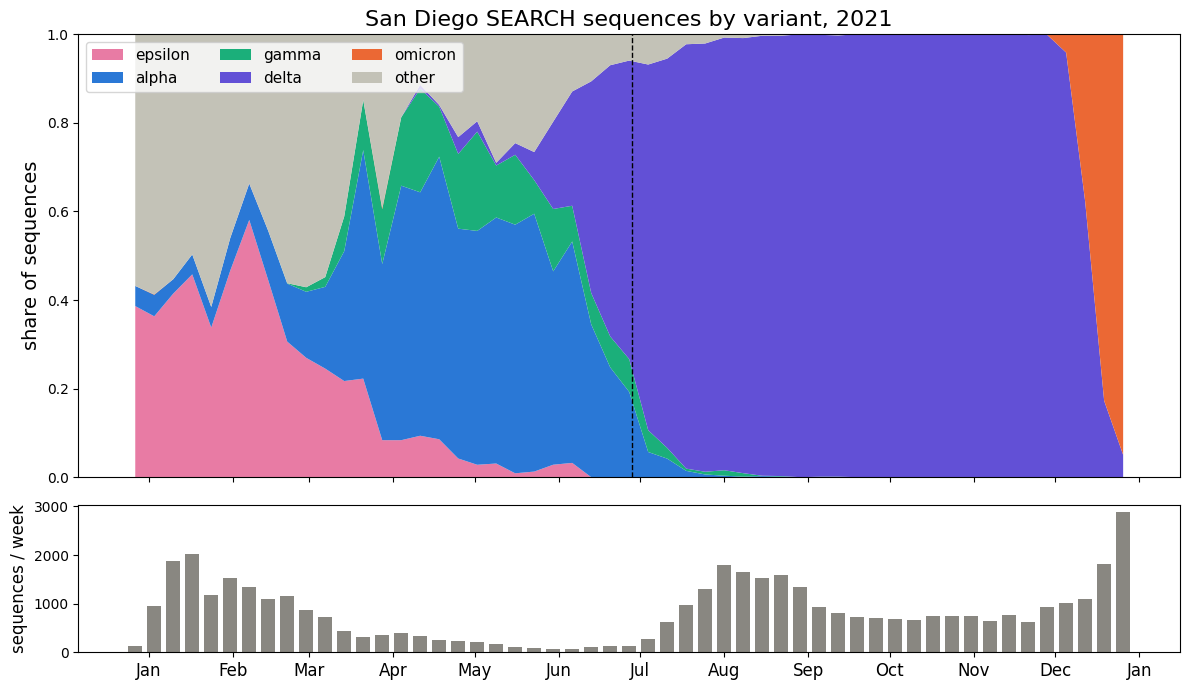

In [22]:
d = df_seq_sd.copy()
d["collection_date"] = pd.to_datetime(d["collection_date"])
d["variant"] = d["lineage"].map(map_variant)
d["week"] = d["collection_date"].dt.to_period("W-SAT").dt.start_time    # weeks starting Sunday

d21 = d[(d["collection_date"] >= "2021-01-01") & (d["collection_date"] <= "2021-12-31")]

counts = pd.crosstab(d21["week"], d21["variant"])
order = [c for c in ["epsilon", "alpha", "gamma", "delta", "omicron", "other"] if c in counts.columns]
counts = counts[order]
share = counts.div(counts.sum(axis=1), axis=0)
n = counts.sum(axis=1)

colors = {"epsilon": "#e87ba4", "alpha": "#2a78d6", "gamma": "#1baf7a",
          "delta": "#6250d6", "omicron": "#eb6834", "other": "#c3c2b7"}

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

# Top: share of sequences by variant
ax[0].stackplot(share.index, [share[c] for c in order],
                labels=order, colors=[colors[c] for c in order])
ax[0].set_ylabel("share of sequences", fontsize=14)
ax[0].set_ylim(0, 1)
ax[0].legend(loc="upper left", ncol=3, fontsize=11)
ax[0].set_title("San Diego SEARCH sequences by variant, 2021", fontsize=16)
ax[0].axvline(pd.Timestamp("2021-06-28"), color="k", ls="--", lw=1)   # Delta window start

# Bottom: how many sequences each week (small n = noisy shares)
ax[1].bar(n.index, n.values, width=5, color="#898781")
ax[1].set_ylabel("sequences / week", fontsize=12)

ax[1].xaxis.set_major_locator(mdates.MonthLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax[1].tick_params(axis="x", labelsize=12)
plt.tight_layout()
plt.show()

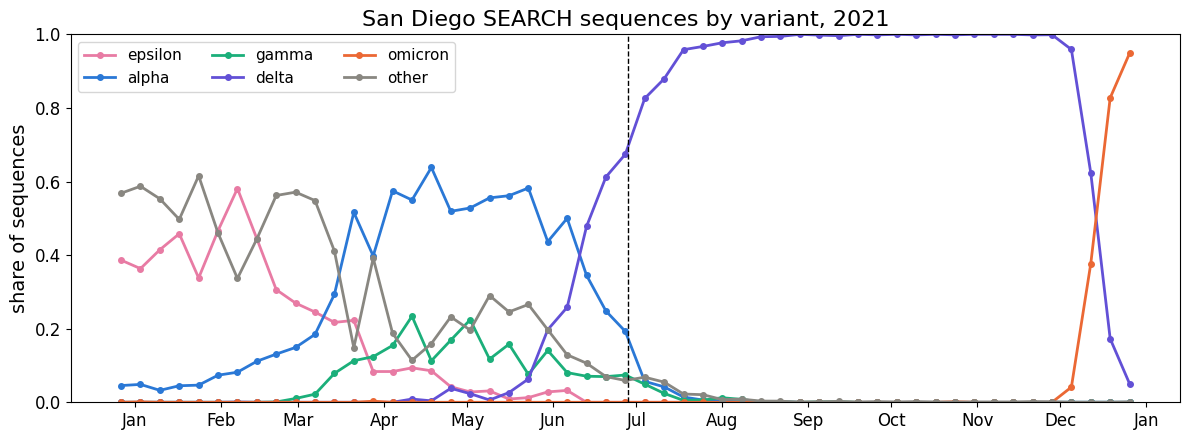

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- Prepare weekly variant shares (2021) ----
dl = df_seq_sd.copy()
dl["collection_date"] = pd.to_datetime(dl["collection_date"])
dl["variant"] = dl["lineage"].map(map_variant)
dl["week"] = dl["collection_date"].dt.to_period("W-SAT").dt.start_time    # weeks starting Sunday

dl21 = dl[(dl["collection_date"] >= "2021-01-01") & (dl["collection_date"] <= "2021-12-31")]

counts_l = pd.crosstab(dl21["week"], dl21["variant"])
order_l = [c for c in ["epsilon", "alpha", "gamma", "delta", "omicron", "other"] if c in counts_l.columns]
counts_l = counts_l[order_l]
share_l = counts_l.div(counts_l.sum(axis=1), axis=0)

colors_l = {"epsilon": "#e87ba4", "alpha": "#2a78d6", "gamma": "#1baf7a",
            "delta": "#6250d6", "omicron": "#eb6834", "other": "#898781"}

# ---- Plot: coloured lines only ----
fig, ax = plt.subplots(figsize=(12, 4.5))

for c in order_l:
    ax.plot(share_l.index, share_l[c], "o-", ms=4, lw=2, color=colors_l[c], label=c)

ax.set_ylabel("share of sequences", fontsize=14)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", ncol=3, fontsize=11)
ax.set_title("San Diego SEARCH sequences by variant, 2021", fontsize=16)
ax.axvline(pd.Timestamp("2021-06-28"), color="k", ls="--", lw=1)    # start of Delta window

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

### Raw share

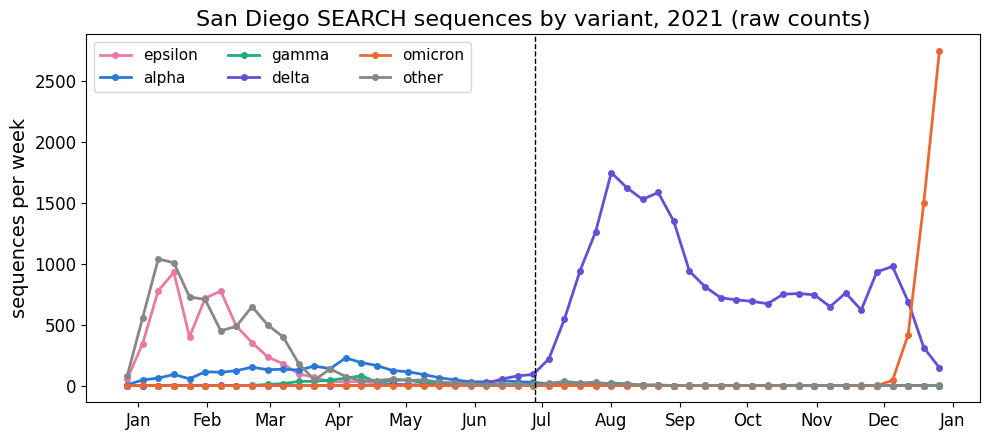

In [32]:
# ---- Prepare weekly variant counts (2021) ----
dl = df_seq_sd.copy()
dl["collection_date"] = pd.to_datetime(dl["collection_date"])
dl["variant"] = dl["lineage"].map(map_variant)
dl["week"] = dl["collection_date"].dt.to_period("W-SAT").dt.start_time    # weeks starting Sunday

dl21 = dl[(dl["collection_date"] >= "2021-01-01") & (dl["collection_date"] <= "2021-12-31")]

counts_l = pd.crosstab(dl21["week"], dl21["variant"])
order_l = [c for c in ["epsilon", "alpha", "gamma", "delta", "omicron", "other"] if c in counts_l.columns]
counts_l = counts_l[order_l]

colors_l = {"epsilon": "#e87ba4", "alpha": "#2a78d6", "gamma": "#1baf7a",
            "delta": "#6250d6", "omicron": "#eb6834", "other": "#898781"}

# ---- Plot: raw sequence counts per week, one coloured line per variant ----
fig, ax = plt.subplots(figsize=(10, 4.5))

for c in order_l:
    ax.plot(counts_l.index, counts_l[c], "o-", ms=4, lw=2, color=colors_l[c], label=c)

ax.set_ylabel("sequences per week", fontsize=14)
ax.legend(loc="upper left", ncol=3, fontsize=11)
ax.set_title("San Diego SEARCH sequences by variant, 2021 (raw counts)", fontsize=16)
ax.axvline(pd.Timestamp("2021-06-28"), color="k", ls="--", lw=1)    # start of Delta window

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

In [26]:
# Totals behind the shares, for the weeks around the Delta window
print(counts_l.assign(total=counts_l.sum(axis=1)).loc["2021-05-15":"2021-08-15"])

variant     epsilon  alpha  gamma  delta  omicron  other  total
week                                                           
2021-05-16        1     64     18      3        0     28    114
2021-05-23        1     46      6      5        0     21     79
2021-05-30        2     31     10     14        0     14     71
2021-06-06        2     31      5     16        0      8     62
2021-06-13        0     39      8     54        0     12    113
2021-06-20        0     32      9     79        0      9    129
2021-06-27        0     26     10     91        0      8    135
2021-07-04        0     15     13    218        0     18    264
2021-07-11        0     26     15    545        0     34    620
2021-07-18        0     14      5    942        0     22    983
2021-07-25        0      8      8   1263        0     27   1306
2021-08-01        0      6     22   1747        0     13   1788
2021-08-08        0      2     13   1622        0     14   1651
2021-08-15        1      3      1   1527

In [28]:
# Total sequences per variant across all of 2021
year_totals = counts_l.sum().to_frame("num_genomes_sequenced")
year_totals["pct_of_2021_genomes"] = (100 * year_totals["num_genomes_sequenced"]
                                      / year_totals["num_genomes_sequenced"].sum()).round(1)
year_totals.loc["total"] = [year_totals["num_genomes_sequenced"].sum(), 100.0]
year_totals.index.name = "variant"
print(year_totals)


         num_genomes_sequenced  pct_of_2021_genomes
variant                                            
epsilon                 5552.0                 12.6
alpha                   2693.0                  6.1
gamma                    562.0                  1.3
delta                  22942.0                 52.2
omicron                 4701.0                 10.7
other                   7495.0                 17.1
total                  43945.0                100.0


In [29]:
##STYLE
styled = (year_totals.style
    .format({"num_genomes_sequenced": "{:,.0f}", "pct_of_2021_genomes": "{:.1f}"})
    .set_table_styles([
        {"selector": "th", "props": [("font-family", "Times New Roman, serif"),
                                     ("font-size", "14pt"), ("font-weight", "bold"),
                                     ("text-align", "center")]},
        {"selector": "td", "props": [("font-family", "Times New Roman, serif"),
                                     ("font-size", "14pt"), ("text-align", "right")]},
    ])
    .set_caption("SEARCH sequenced genomes by variant, San Diego, 2021")
)
styled

,num_genomes_sequenced,pct_of_2021_genomes
variant,,
epsilon,"5,552",12.6
alpha,"2,693",6.1
gamma,562,1.3
delta,"22,942",52.2
omicron,"4,701",10.7
other,"7,495",17.1
total,"43,945",100.0


## Part 3: Point Loma Sequences!!

In [40]:
df_seq_sd["zipcode"].isna().value_counts()

zipcode
False    83586
True      6831
Name: count, dtype: int64

In [37]:
# ---- Clean the sequence zip codes (text, may have ".0" or "nan") ----
seq = df_seq_sd.copy()
seq["zip"] = (seq["zipcode"].astype(str)
                 .str.replace(r"\.0$", "", regex=True)      # "92109.0" -> "92109"
                 .str.strip())
seq["zip"] = pd.to_numeric(seq["zip"], errors="coerce")      # "nan" / junk -> NaN

print(seq["zip"].isna().sum(), "of", len(seq), "sequences have no usable zip")

# ---- Zip table: same type, Point Loma only ----
zips_pl = zips.copy()
zips_pl["zip"] = zips_pl["Zip_code"].astype(int)
zips_pl = zips_pl[zips_pl["Wastewater_treatment_plant"] == "Point Loma"][["zip", "Community"]]

# ---- Join: inner keeps only sequences from Point Loma zips ----
seq_pl = seq.merge(zips_pl, on="zip", how="inner", validate="m:1")

print(len(seq), "San Diego sequences ->", len(seq_pl), "Point Loma sequences")
print(seq_pl["collection_date"].min(), seq_pl["collection_date"].max())

6831 of 90417 sequences have no usable zip
90417 San Diego sequences -> 59541 Point Loma sequences
2020-03-04 00:00:00 2024-02-28 00:00:00


In [41]:
  seq["has_zip"] = seq["zip"].notna()
  seq["month"] = pd.to_datetime(seq["collection_date"]).dt.to_period("M")
  print(seq.groupby("month")["has_zip"].mean().loc["2021-03":"2021-09"].round(2))

month
2021-03    0.94
2021-04    0.93
2021-05    0.89
2021-06    0.81
2021-07    0.82
2021-08    0.84
2021-09    0.92
Freq: M, Name: has_zip, dtype: float64


In [43]:
seq["variant"] = seq["lineage"].map(map_variant)
seq["collection_date"] = pd.to_datetime(seq["collection_date"])
d = seq[(seq["collection_date"] >= "2021-06-14") & (seq["collection_date"] <= "2021-07-11")]
print(pd.crosstab(d["has_zip"], d["variant"], normalize="index").round(2))
print(d["has_zip"].value_counts())

variant  alpha  delta  gamma  other
has_zip                            
False     0.24   0.58   0.07   0.11
True      0.15   0.74   0.05   0.06
has_zip
True     547
False    153
Name: count, dtype: int64


In [44]:
# 1. Is the no-zip group just earlier in the window?
print(d.groupby("has_zip")["collection_date"].agg(["min", "median", "max"]))

# 2. Weekly mix, all San Diego (no zip needed), around the start date
d["week"] = d["collection_date"].dt.to_period("W-SAT").dt.start_time
t = pd.crosstab(d["week"], d["variant"])
t["total"] = t.sum(axis=1)
print(t)
print(pd.crosstab(d["week"], d["variant"], normalize="index").round(2))

               min     median        max
has_zip                                 
False   2021-06-14 2021-06-30 2021-07-11
True    2021-06-14 2021-07-03 2021-07-11
variant     alpha  delta  gamma  other  total
week                                         
2021-06-13     36     52      8     11    107
2021-06-20     32     79      9      9    129
2021-06-27     26     91     10      8    135
2021-07-04     15    218     13     18    264
2021-07-11      7     55      1      2     65
variant     alpha  delta  gamma  other
week                                  
2021-06-13   0.34   0.49   0.07   0.10
2021-06-20   0.25   0.61   0.07   0.07
2021-06-27   0.19   0.67   0.07   0.06
2021-07-04   0.06   0.83   0.05   0.07
2021-07-11   0.11   0.85   0.02   0.03


/tmp/ipykernel_2932220/377256800.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["week"] = d["collection_date"].dt.to_period("W-SAT").dt.start_time


In [45]:
seq_pl["variant"] = seq_pl["lineage"].map(map_variant)
seq_pl["collection_date"] = pd.to_datetime(seq_pl["collection_date"])
seq_pl["week"] = seq_pl["collection_date"].dt.to_period("W-SAT").dt.start_time

x = seq_pl[(seq_pl["collection_date"] >= "2021-06-14") & (seq_pl["collection_date"] <= "2021-07-11")]
t = pd.crosstab(x["week"], x["variant"])
t["total"] = t.sum(axis=1)
print(t)
print(pd.crosstab(x["week"], x["variant"], normalize="index").round(2))

variant     alpha  delta  gamma  other  total
week                                         
2021-06-13     20     39      3      6     68
2021-06-20     16     51      5      4     76
2021-06-27      8     53      4      3     68
2021-07-04      6    148     12      9    175
2021-07-11      2     41      1      2     46
variant     alpha  delta  gamma  other
week                                  
2021-06-13   0.29   0.57   0.04   0.09
2021-06-20   0.21   0.67   0.07   0.05
2021-06-27   0.12   0.78   0.06   0.04
2021-07-04   0.03   0.85   0.07   0.05
2021-07-11   0.04   0.89   0.02   0.04


## PLOT POINT LOMA SEQUENCES

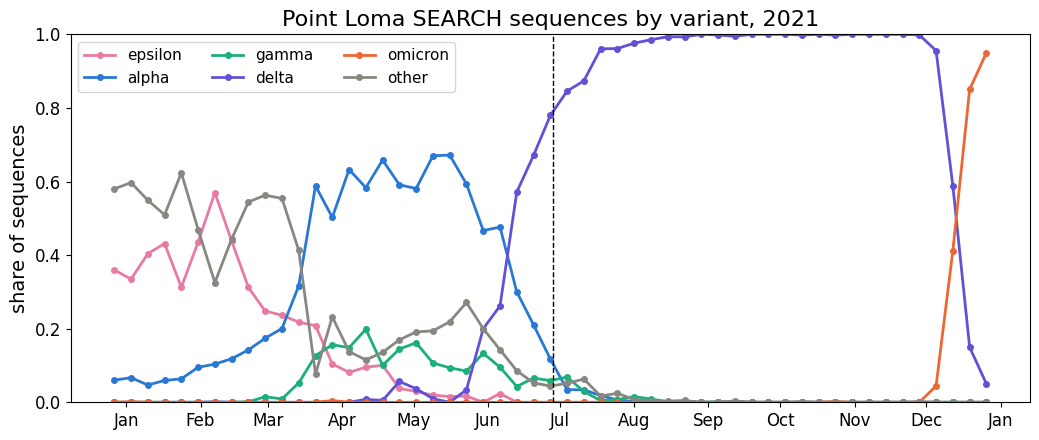

In [53]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- Prepare weekly variant shares (2021) ----
dp = seq_pl.copy() 
dp["collection_date"] = pd.to_datetime(dp["collection_date"])
dp["variant"] = dp["lineage"].map(map_variant)
dp["week"] = dp["collection_date"].dt.to_period("W-SAT").dt.start_time    # weeks starting Sunday

dp21 = dp[(dp["collection_date"] >= "2021-01-01") & (dp["collection_date"] <= "2021-12-31")]

counts_l = pd.crosstab(dp21["week"], dp21["variant"])
order_l = [c for c in ["epsilon", "alpha", "gamma", "delta", "omicron", "other"] if c in counts_l.columns]
counts_l = counts_l[order_l]
share_l = counts_l.div(counts_l.sum(axis=1), axis=0)

colors_l = {"epsilon": "#e87ba4", "alpha": "#2a78d6", "gamma": "#1baf7a",
            "delta": "#6250d6", "omicron": "#eb6834", "other": "#898781"}

# ---- Plot: coloured lines only ----
fig, ax = plt.subplots(figsize=(10.5, 4.5))

for c in order_l:
    ax.plot(share_l.index, share_l[c], "o-", ms=4, lw=2, color=colors_l[c], label=c)

ax.set_ylabel("share of sequences", fontsize=14)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", ncol=3, fontsize=11)
ax.set_title("Point Loma SEARCH sequences by variant, 2021", fontsize=16)
ax.axvline(pd.Timestamp("2021-06-28"), color="k", ls="--", lw=1)    # start of Delta window

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

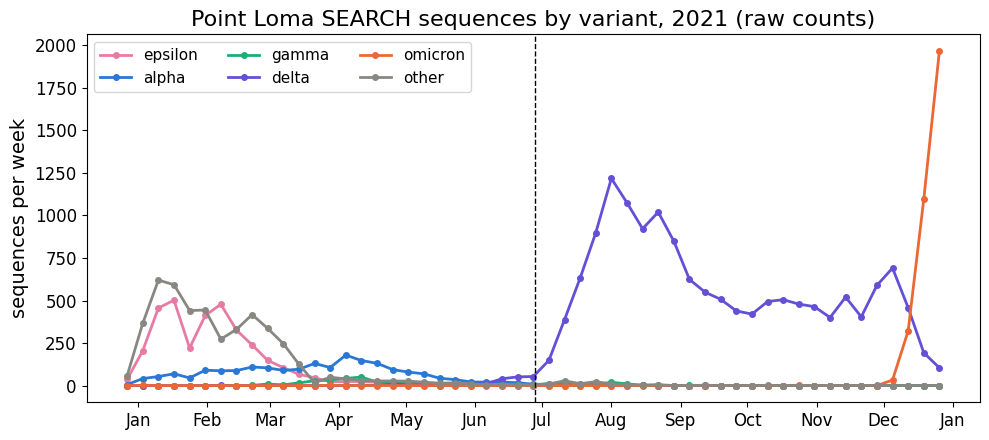

In [46]:
# ---- Prepare weekly variant counts for Point Loma (2021) ----
dp = seq_pl.copy()                                         # Point Loma sequences (zip-joined table)
dp["collection_date"] = pd.to_datetime(dp["collection_date"])
dp["variant"] = dp["lineage"].map(map_variant)
dp["week"] = dp["collection_date"].dt.to_period("W-SAT").dt.start_time    # weeks starting Sunday

dp21 = dp[(dp["collection_date"] >= "2021-01-01") & (dp["collection_date"] <= "2021-12-31")]

counts_p = pd.crosstab(dp21["week"], dp21["variant"])
order_p = [c for c in ["epsilon", "alpha", "gamma", "delta", "omicron", "other"] if c in counts_p.columns]
counts_p = counts_p[order_p]

colors_p = {"epsilon": "#e87ba4", "alpha": "#2a78d6", "gamma": "#1baf7a",
            "delta": "#6250d6", "omicron": "#eb6834", "other": "#898781"}

# ---- Plot: raw sequence counts per week, one coloured line per variant ----
fig, ax = plt.subplots(figsize=(10, 4.5))

for c in order_p:
    ax.plot(counts_p.index, counts_p[c], "o-", ms=4, lw=2, color=colors_p[c], label=c)

ax.set_ylabel("sequences per week", fontsize=14)
ax.legend(loc="upper left", ncol=3, fontsize=11)
ax.set_title("Point Loma SEARCH sequences by variant, 2021 (raw counts)", fontsize=16)
ax.axvline(pd.Timestamp("2021-06-28"), color="k", ls="--", lw=1)    # start of Delta window

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

In [48]:
cmp = pd.DataFrame({
    "county": counts_l.sum(),          # from the San Diego plot
    "point_loma": counts_p.sum(),      # from this plot
})
cmp["pl_share"] = (cmp["point_loma"] / cmp["county"]).round(2)
print(cmp)
print(counts_l.max().to_dict())
print(counts_p.max().to_dict())

         county  point_loma  pl_share
variant                              
epsilon    5552        3345      0.60
alpha      2693        2019      0.75
gamma       562         361      0.64
delta     22942       15174      0.66
omicron    4701        3418      0.73
other      7495        4638      0.62
{'epsilon': 928, 'alpha': 227, 'gamma': 80, 'delta': 1747, 'omicron': 2744, 'other': 1039}
{'epsilon': 502, 'alpha': 179, 'gamma': 50, 'delta': 1218, 'omicron': 1967, 'other': 620}


In [49]:
# Total sequences per variant across all of 2021
year_totals_pl = counts_p.sum().to_frame("num_genomes_sequenced")
year_totals_pl["pct_of_2021_genomes"] = (100 * year_totals_pl["num_genomes_sequenced"]
                                      / year_totals_pl["num_genomes_sequenced"].sum()).round(1)
year_totals_pl.loc["total"] = [year_totals_pl["num_genomes_sequenced"].sum(), 100.0]
year_totals_pl.index.name = "variant"
print(year_totals_pl)


         num_genomes_sequenced  pct_of_2021_genomes
variant                                            
epsilon                 3345.0                 11.6
alpha                   2019.0                  7.0
gamma                    361.0                  1.2
delta                  15174.0                 52.4
omicron                 3418.0                 11.8
other                   4638.0                 16.0
total                  28955.0                100.0


In [50]:
##STYLE
styled = (year_totals_pl.style
    .format({"num_genomes_sequenced": "{:,.0f}", "pct_of_2021_genomes": "{:.1f}"})
    .set_table_styles([
        {"selector": "th", "props": [("font-family", "Times New Roman, serif"),
                                     ("font-size", "14pt"), ("font-weight", "bold"),
                                     ("text-align", "center")]},
        {"selector": "td", "props": [("font-family", "Times New Roman, serif"),
                                     ("font-size", "14pt"), ("text-align", "right")]},
    ])
    .set_caption("SEARCH sequenced genomes by variant, Point Loma, 2021")
)
styled

,num_genomes_sequenced,pct_of_2021_genomes
variant,,
epsilon,"3,345",11.6
alpha,"2,019",7.0
gamma,361,1.2
delta,"15,174",52.4
omicron,"3,418",11.8
other,"4,638",16.0
total,"28,955",100.0
